In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
)
from src.plotting import (
    make_animation,
    plot
)
from src.analysis.classifiers import classify_temporal_behavior
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from skimage import measure
import xarray as xr

In [8]:
df0 = pd.DataFrame()
frames = []
for ds_id in ["transfer2"]:
    ds, output_dir = get_dataset("bruss", ds_id, "SCRATCHDIR")
    df = ds.df
    # if ds_id == "param_sweep":
    #     df['pca_label'] = df['pca_label'].map({2: 0, 0: 1, 1: 2})
    # elif ds_id == "rough":
    #     df['pca_label'] = df['pca_label'].map({2: 1, 0: 2, 1: 0})
    # elif ds_id == "rough2":
    #     df['pca_label'] = df['pca_label'].map({2: 1, 0: 2, 1: 0})
    df['dataset'] = ds_id
    df0 = pd.concat([df0, df])
df = df0
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [9]:
fig = px.scatter_3d(
    df,
    x="A",
    y="ratio_d",
    z="mean_deviation", 
    color="dataset", 
    hover_data={"idx": True},
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

In [47]:
df.A

0      4.839961
8      1.967208
9      4.904350
14     2.163932
18     5.027165
         ...   
553    1.877423
554    5.169682
556    5.147734
561    4.509310
569    4.516111
Name: A, Length: 147, dtype: float64

In [36]:
df = df[(df.ratio_d < 9) & (df.ratio_b_a > 1.5)]

In [11]:
ds2, output_dir = get_dataset("bruss", "transfer", "SCRATCHDIR")


[830 164 236]


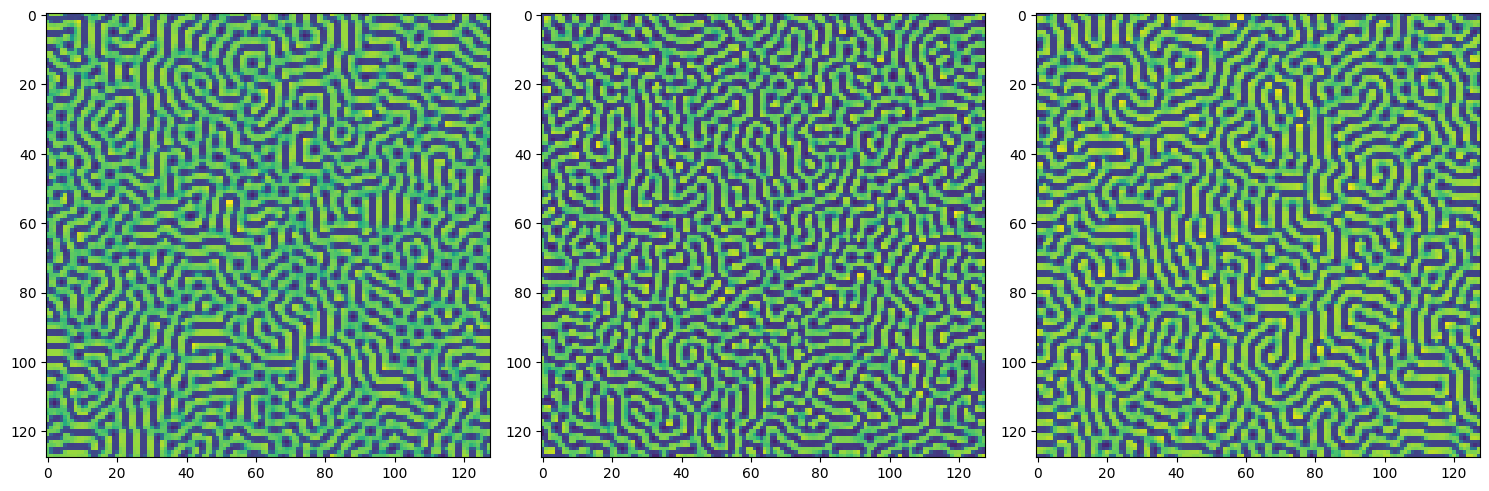

In [19]:
# df_sub = df[df.A > 3]
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sub_indices = df["idx"].sample(3).values
print(sub_indices)
for i, idx in enumerate(sub_indices):
    traj = ds.get_data(idx)
    ff = traj[-1,0] # :, 0::2]
    # plot(ff, ax=ax[i], title=f"Pattern Class {pc}, Trajectory {idx}")
    ax[i].imshow(ff, cmap="viridis", vmin=0)
plt.tight_layout()
plt.show()